In [1]:
import pandas as pd
import os
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np



In [2]:
import ast

# ── Load data ──────────────────────────────────────────────────────────────────
cn_df  = pd.read_csv("datasets/Dataset_v2_1/pooled_CN.csv")
lead_time_cn_df  = pd.read_csv("datasets/Dataset_v2_1/lead_time_CN.csv")
mci_df = pd.read_csv("datasets/Dataset_v2_1/pooled_MCI_AD.csv")
lead_time_mci_df = pd.read_csv("datasets/Dataset_v2_1/lead_time_MCI_AD.csv")

def parse_prog(s):
    return ast.literal_eval(s)

for df in [cn_df, lead_time_cn_df, mci_df, lead_time_mci_df]:
    df["prog_tuple"] = df["Progression"].apply(parse_prog)
    df["n_visits"]   = df["prog_tuple"].apply(len)

cn_df["is_progressor"]          = cn_df["prog_tuple"].apply(lambda t: any(x != 0 for x in t))
lead_time_cn_df["is_progressor"]= lead_time_cn_df["prog_tuple"].apply(lambda t: any(x != 0 for x in t))
mci_df["is_progressor"]         = mci_df["prog_tuple"].apply(lambda t: any(x == 2 for x in t))
lead_time_mci_df["is_progressor"]= lead_time_mci_df["prog_tuple"].apply(lambda t: any(x == 2 for x in t))

# ── Combine pooled + lead_time DataFrames ──────────────────────────────────────
combined_cn_df  = pd.concat([cn_df, lead_time_cn_df], ignore_index=True)
combined_mci_df = pd.concat([mci_df, lead_time_mci_df], ignore_index=True)

visit_counts = [2, 3, 4, 5, 6, 7, 8, 9, 10]

groups = {
    "CN Non-Prog":  combined_cn_df[~combined_cn_df["is_progressor"]],
    "CN Prog":      combined_cn_df[combined_cn_df["is_progressor"]],
    "MCI Non-Prog": combined_mci_df[~combined_mci_df["is_progressor"]],
    "MCI Prog":     combined_mci_df[combined_mci_df["is_progressor"]],
}

counts = {
    label: [int((df["n_visits"] == v).sum()) for v in visit_counts]
    for label, df in groups.items()
}

colors = ["#4393C3", "#2166AC", "#D6604D", "#B2182B"]

fig, ax = plt.subplots(figsize=(14, 8))

n_groups = len(visit_counts)
n_bars   = len(groups)
bar_w    = 0.18
x        = np.arange(n_groups)

for i, (label, color) in enumerate(zip(groups.keys(), colors)):
    offsets = x + (i - (n_bars - 1) / 2) * bar_w
    bars = ax.bar(offsets, counts[label], bar_w,
                  label=label, color=color, edgecolor="white", linewidth=0.8, zorder=3)

ax.set_xticks(x)
ax.set_xticklabels([f"{v}" for v in visit_counts], fontsize=20, fontweight="bold")
ax.set_ylabel("Number of Participants", fontsize=20, fontweight="bold", labelpad=12)
ax.set_xlabel("Number of Visits", fontsize=20, fontweight="bold", labelpad=12)

ax.set_ylim(0, 3000)
ax.set_yticks(range(0, 3001, 500))

ax.tick_params(axis="y", labelsize=17)
ax.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.6, zorder=0)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

legend = ax.legend(
    title="Group", title_fontsize=18,
    fontsize=17, frameon=True, framealpha=0.9,
    edgecolor="#cccccc", loc="upper right"
)

plt.tight_layout()
plt.savefig("poster_group_barchart.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved → poster_group_barchart.png")

summary = pd.DataFrame(counts, index=[f"{v} Visits" for v in visit_counts])
summary.index.name = "Number of Visits"
print(summary)

summary.to_excel("group_visit_counts.xlsx")
print("Saved → group_visit_counts.xlsx")


FileNotFoundError: [Errno 2] No such file or directory: 'datasets/Dataset_v2_1/pooled_CN.csv'

# Results

## General conventions
- No 3-D perspective effects.
- Show shaded 95% confidence intervals on aggregate mean curves.  
### Aggregate Curves
- Compare classifer of MICE variant runs aggregated together vs non-imputed classifier with random splits. Both have 10 runs to average. 

# Results

## General conventions
- No 3-D perspective effects.
- Show shaded 95% confidence intervals on aggregate mean curves.  
### Aggregate Curves
- Compare classifer of MICE variant runs aggregated together vs non-imputed classifier with random splits. Both have 10 runs to average. 

## ROC-AUC Curve

CN_MCI non-imputed runs:      10
MCI_AD non-imputed runs:      10
pooled_CN MICE runs:          10
pooled_MCI_AD MICE runs:      10


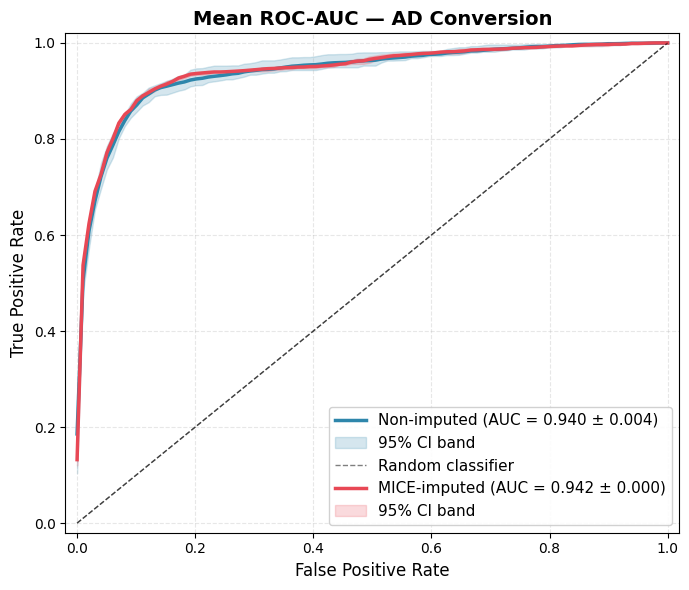

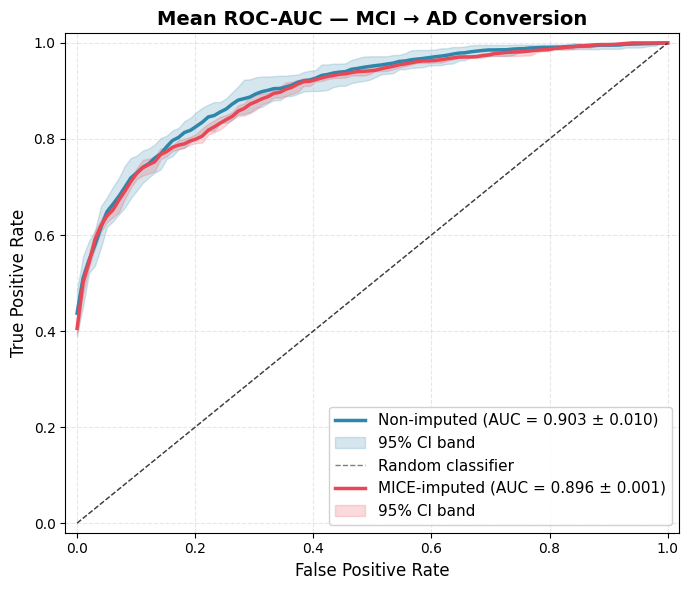

In [ ]:
import glob
from visualization import plot_aggregate_roc

NON_IMPUTED_DIR = os.path.join("experiments", "experiment_non_imputed_final", "artifacts")
MICE_DIR        = os.path.join("experiments", "experiment_mice_imputed_final", "artifacts")


def load_runs(artifacts_dir, dataset_prefix, split_marker):
    """Load y_true/y_proba arrays for every run of a dataset within an artifacts folder.

    Parameters
    ----------
    artifacts_dir : str
        Path to an experiment's `artifacts/` folder.
    dataset_prefix : str
        Base dataset name, e.g. 'CN_MCI' or 'pooled_CN'.
    split_marker : str
        Substring used to split a run key into base dataset + run id,
        e.g. '_seed' (non-imputed) or '_variant' (MICE-imputed).

    Returns
    -------
    y_true_list, y_proba_list : list[np.ndarray]
    """
    y_true_files = sorted(glob.glob(os.path.join(artifacts_dir, f"{dataset_prefix}{split_marker}*_y_true.npy")))
    y_true_list, y_proba_list = [], []
    for yt_path in y_true_files:
        key = os.path.basename(yt_path).replace('_y_true.npy', '')
        base = key.split(split_marker)[0]
        if base != dataset_prefix:
            continue
        yp_path = os.path.join(artifacts_dir, f"{key}_y_proba.npy")
        y_true_list.append(np.load(yt_path))
        y_proba_list.append(np.load(yp_path))
    return y_true_list, y_proba_list


def dedupe_legend(ax, loc):
    """Keep only the first 'Random classifier' baseline entry to avoid duplicate legend rows."""
    seen_random = False
    handles, labels = ax.get_legend_handles_labels()
    new_handles, new_labels = [], []
    for h, l in zip(handles, labels):
        if l.startswith('Random classifier'):
            if seen_random:
                continue
            seen_random = True
        new_handles.append(h)
        new_labels.append(l)
    ax.legend(new_handles, new_labels, loc=loc, fontsize=11, framealpha=0.9)


# ── Load runs for each dataset / imputation strategy ───────────────────────────
cn_mci_nonimp_yt, cn_mci_nonimp_yp     = load_runs(NON_IMPUTED_DIR, "CN_MCI", "_seed")
mci_ad_nonimp_yt, mci_ad_nonimp_yp     = load_runs(NON_IMPUTED_DIR, "MCI_AD", "_seed")
pooled_cn_mice_yt, pooled_cn_mice_yp   = load_runs(MICE_DIR, "pooled_CN", "_variant")
pooled_mci_mice_yt, pooled_mci_mice_yp = load_runs(MICE_DIR, "pooled_MCI_AD", "_variant")

print(f"CN_MCI non-imputed runs:      {len(cn_mci_nonimp_yt)}")
print(f"MCI_AD non-imputed runs:      {len(mci_ad_nonimp_yt)}")
print(f"pooled_CN MICE runs:          {len(pooled_cn_mice_yt)}")
print(f"pooled_MCI_AD MICE runs:      {len(pooled_mci_mice_yt)}")


def plot_comparison_roc(nonimp_yt, nonimp_yp, mice_yt, mice_yp, title, save_path=None):
    fig, ax = plt.subplots(figsize=(7, 6))
    plot_aggregate_roc(nonimp_yt, nonimp_yp, label="Non-imputed", color="#2E86AB", ax=ax)
    plot_aggregate_roc(mice_yt, mice_yp, label="MICE-imputed", color="#E84855", ax=ax)

    dedupe_legend(ax, loc="lower right")
    ax.set_title(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


plot_comparison_roc(
    cn_mci_nonimp_yt, cn_mci_nonimp_yp,
    pooled_cn_mice_yt, pooled_cn_mice_yp,
    title="Mean ROC-AUC — AD Conversion",
    save_path=os.path.join("charts", "paper", "roc_cn_mci_comparison.png"),
)

plot_comparison_roc(
    mci_ad_nonimp_yt, mci_ad_nonimp_yp,
    pooled_mci_mice_yt, pooled_mci_mice_yp,
    title="Mean ROC-AUC — AD Conversion",
    save_path=os.path.join("charts", "paper", "roc_mci_ad_comparison.png"),
)


## PR-AUC Curve

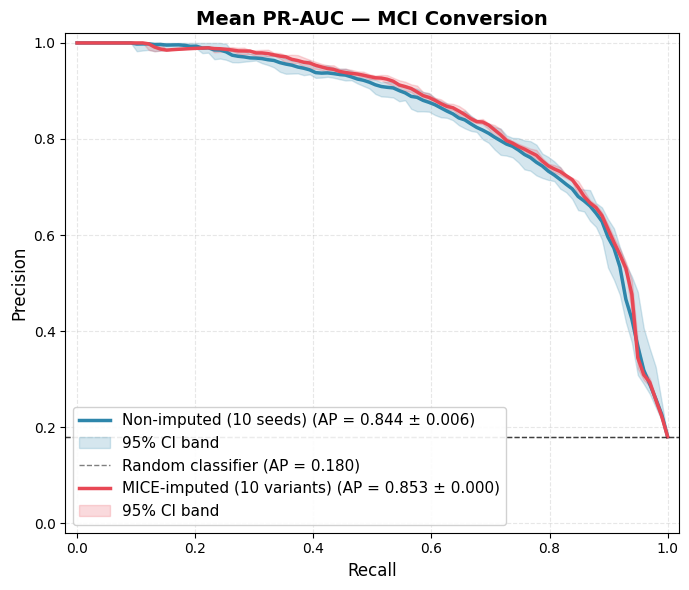

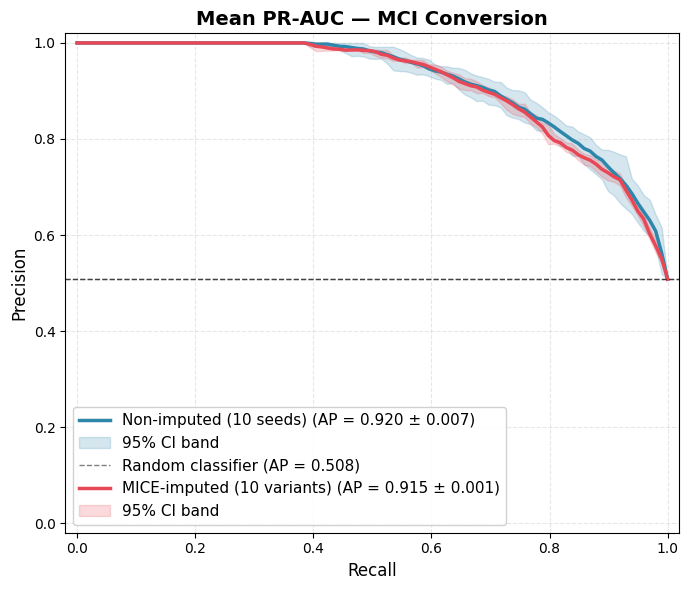

In [7]:
from visualization import plot_aggregate_pr


def plot_comparison_pr(nonimp_yt, nonimp_yp, mice_yt, mice_yp, title, save_path=None):
    fig, ax = plt.subplots(figsize=(7, 6))
    plot_aggregate_pr(nonimp_yt, nonimp_yp, label="Non-imputed (10 seeds)", color="#2E86AB", ax=ax)
    plot_aggregate_pr(mice_yt, mice_yp, label="MICE-imputed (10 variants)", color="#E84855", ax=ax)

    dedupe_legend(ax, loc="lower left")
    ax.set_title(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


plot_comparison_pr(
    cn_mci_nonimp_yt, cn_mci_nonimp_yp,
    pooled_cn_mice_yt, pooled_cn_mice_yp,
    title="Mean PR-AUC — MCI Conversion",
    save_path=os.path.join("charts", "paper", "pr_cn_mci_comparison.png"),
)

plot_comparison_pr(
    mci_ad_nonimp_yt, mci_ad_nonimp_yp,
    pooled_mci_mice_yt, pooled_mci_mice_yp,
    title="Mean PR-AUC — MCI Conversion",
    save_path=os.path.join("charts", "paper", "pr_mci_ad_comparison.png"),
)


#### Aggregate figure

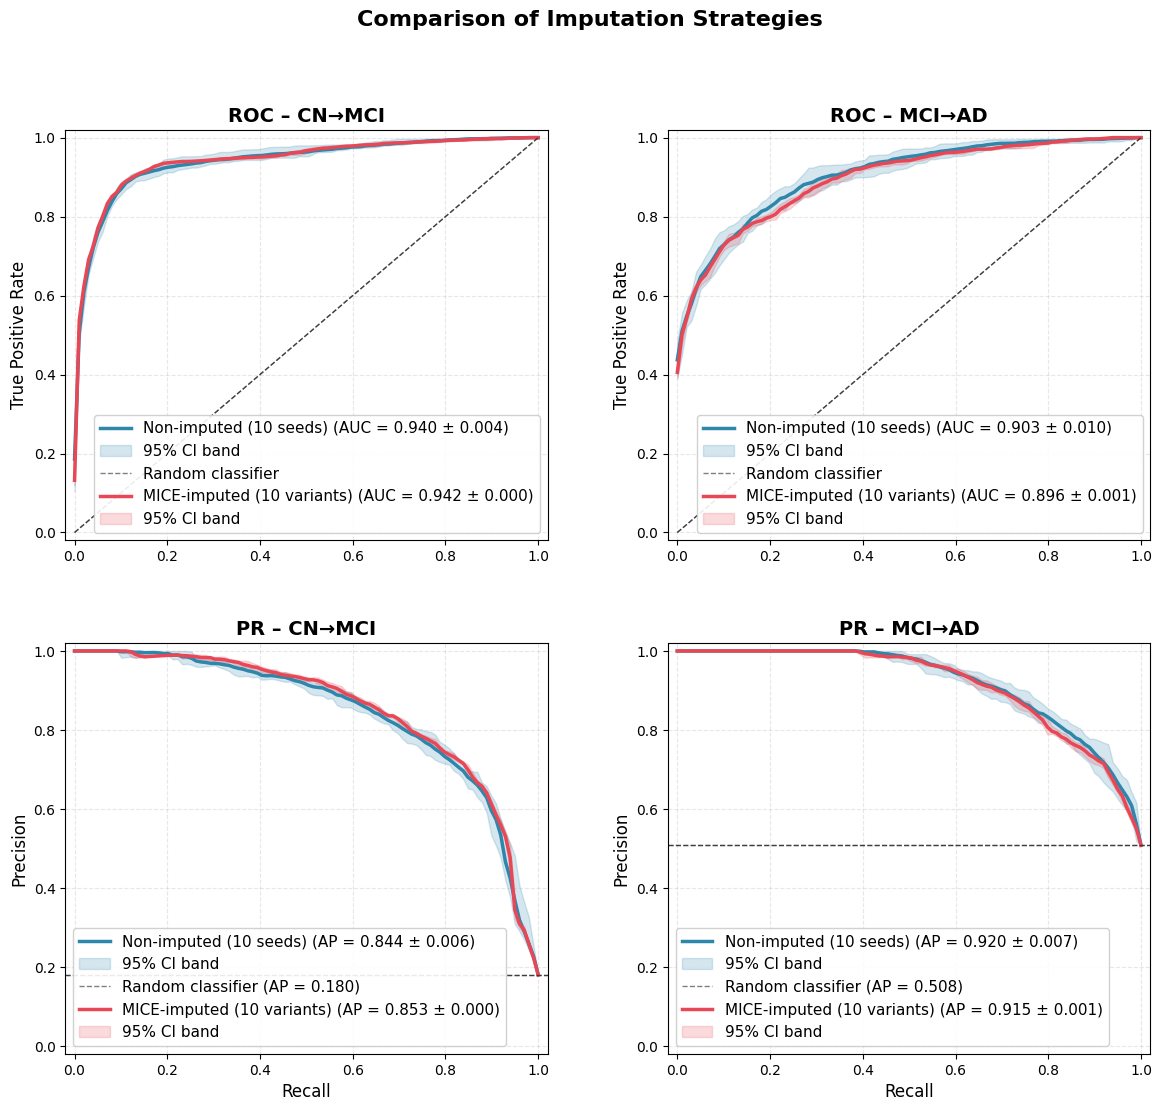

Combined figure saved to: charts/paper/aggregate_roc_pr_grid.png


In [10]:
import matplotlib.pyplot as plt
import numpy as np
import os
from visualization import plot_aggregate_roc, plot_aggregate_pr

# ── Create 2×2 figure ──────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 12))
gs = fig.add_gridspec(2, 2, hspace=0.25, wspace=0.25)

# Define subplots
ax_roc_cn = fig.add_subplot(gs[0, 0])
ax_roc_ad = fig.add_subplot(gs[0, 1])
ax_pr_cn  = fig.add_subplot(gs[1, 0])
ax_pr_ad  = fig.add_subplot(gs[1, 1])

# ── Plot ROC curves ──────────────────────────────────────────────────────────
plot_aggregate_roc(cn_mci_nonimp_yt, cn_mci_nonimp_yp,
                   label="Non‑imputed (10 seeds)", color="#2E86AB", ax=ax_roc_cn)
plot_aggregate_roc(pooled_cn_mice_yt, pooled_cn_mice_yp,
                   label="MICE‑imputed (10 variants)", color="#E84855", ax=ax_roc_cn)
ax_roc_cn.set_title("ROC – CN→MCI", fontsize=14, fontweight="bold")
# Remove duplicate random baseline
dedupe_legend(ax_roc_cn, loc="lower right")

plot_aggregate_roc(mci_ad_nonimp_yt, mci_ad_nonimp_yp,
                   label="Non‑imputed (10 seeds)", color="#2E86AB", ax=ax_roc_ad)
plot_aggregate_roc(pooled_mci_mice_yt, pooled_mci_mice_yp,
                   label="MICE‑imputed (10 variants)", color="#E84855", ax=ax_roc_ad)
ax_roc_ad.set_title("ROC – MCI→AD", fontsize=14, fontweight="bold")
dedupe_legend(ax_roc_ad, loc="lower right")

# ── Plot PR curves ──────────────────────────────────────────────────────────
plot_aggregate_pr(cn_mci_nonimp_yt, cn_mci_nonimp_yp,
                  label="Non‑imputed (10 seeds)", color="#2E86AB", ax=ax_pr_cn)
plot_aggregate_pr(pooled_cn_mice_yt, pooled_cn_mice_yp,
                  label="MICE‑imputed (10 variants)", color="#E84855", ax=ax_pr_cn)
ax_pr_cn.set_title("PR – CN→MCI", fontsize=14, fontweight="bold")
dedupe_legend(ax_pr_cn, loc="lower left")

plot_aggregate_pr(mci_ad_nonimp_yt, mci_ad_nonimp_yp,
                  label="Non‑imputed (10 seeds)", color="#2E86AB", ax=ax_pr_ad)
plot_aggregate_pr(pooled_mci_mice_yt, pooled_mci_mice_yp,
                  label="MICE‑imputed (10 variants)", color="#E84855", ax=ax_pr_ad)
ax_pr_ad.set_title("PR – MCI→AD", fontsize=14, fontweight="bold")
dedupe_legend(ax_pr_ad, loc="lower left")

# ── Common x‑axis labels (hide duplicates) ───────────────────────────────────
ax_roc_cn.set_xlabel("")
ax_roc_ad.set_xlabel("")
ax_pr_cn.set_xlabel("False Positive Rate" if ax_pr_cn else "")
ax_pr_ad.set_xlabel("False Positive Rate" if ax_pr_ad else "")
# Actually we want proper labels:
ax_pr_cn.set_xlabel("Recall")
ax_pr_ad.set_xlabel("Recall")
# For ROC, xlabel already set inside plot_aggregate_roc, but we can keep.

# ── Optional: add a global suptitle ─────────────────────────────────────────
fig.suptitle("Comparison of Imputation Strategies", fontsize=16, fontweight="bold", y=0.98)

# ── Save figure ──────────────────────────────────────────────────────────────
save_path = os.path.join("charts", "paper", "aggregate_roc_pr_grid.png")
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Combined figure saved to: {save_path}")

## SHAP Feature Charts

## Feature Importance Charts

## Lead Time Analysis
